## Imports and Setup

In [1]:
import torch
torch.cuda.empty_cache() 

In [2]:
torch.cuda.set_device(1)

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from transformers import LlamaTokenizer, LlamaForCausalLM
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/b22cs092/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [5]:
import torch
torch.cuda.empty_cache()

In [6]:
print("GPUs Available:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

GPUs Available: 1
GPU 0: NVIDIA L40S


In [ ]:
print(torch.cuda.current_device())

1


In [9]:
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1')

print("Sample from WikiText-2:")
for i in range(5):
    print(f"Example {i}: {repr(dataset['train'][i]['text'][:100])}...")

Sample from WikiText-2:
Example 0: ''...
Example 1: ' = Valkyria Chronicles III = \n'...
Example 2: ''...
Example 3: ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battle'...
Example 4: ' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chr'...


### Tokenizer

In [10]:
def tokenize_function(examples):
    inputs = tokenizer(
        examples['text'], 
        truncation=True, 
        padding='max_length', 
        max_length=512,
        return_attention_mask=True,
    )
    inputs['labels'] = inputs['input_ids'].copy()
    return inputs

## GPT-2

In [14]:
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2").to(device)



In [15]:
# Set the EOS token as the padding token
tokenizer.pad_token = tokenizer.eos_token

In [16]:
model.config.pad_token_id = tokenizer.pad_token_id

In [17]:
tokenized_datasets = dataset.map(tokenize_function, batched=True)

In [18]:
tokenized_datasets

DatasetDict({
    test: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3760
    })
})

In [19]:
tokenized_datasets['train']

Dataset({
    features: ['text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 36718
})

In [16]:
training_args = TrainingArguments(
    output_dir='kv/results',
    eval_strategy='epoch',
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='kv/logs'
)

In [17]:
import os
os.makedirs("kv", exist_ok=True)


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
)


In [17]:

trainer.train()

model_output_dir = 'kv/results/model'

model.save_pretrained(model_output_dir)
tokenizer.save_pretrained(model_output_dir)

/home/b22cs092/.local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.425800,0.418304


/home/b22cs092/.local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/b22cs092/.local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/b22cs092/.local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/b22cs092/.local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/b22cs092/.local/lib/python3.12/site-packages/torch

('kv/results/model/tokenizer_config.json',
 'kv/results/model/special_tokens_map.json',
 'kv/results/model/vocab.json',
 'kv/results/model/merges.txt',
 'kv/results/model/added_tokens.json',
 'kv/results/model/tokenizer.json')

In [26]:
print(type(model))


<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


In [27]:
print(tokenizer.model_max_length)
print(tokenizer.padding_side)


1024
right


## TinyLlama

In [28]:
import time
import numpy as np
import pandas as pd

In [14]:
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [31]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer.pad_token = tokenizer.eos_token
model.generation_config.pad_token_id = tokenizer.pad_token_id

In [33]:
tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map: 100%|███████████████████████████████████████████████████████████████| 36718/36718 [00:06<00:00, 5886.00 examples/s]


In [34]:
tokenized_datasets

DatasetDict({
    test: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3760
    })
})

In [24]:
model.train()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb): 

In [25]:
training_args = TrainingArguments(
    output_dir='kv/results_llama',
    eval_strategy='epoch',
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    warmup_steps=500,
    weight_decay=0.01,
    dataloader_num_workers=0,       # Disable multiprocessing
    dataloader_pin_memory=False, 
    logging_dir='kv/logs_llama'
)

In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
)

In [27]:
import gc
torch.cuda.empty_cache()
gc.collect()

46

In [31]:

trainer.train()

model_output_dir = 'kv/results_llama/model'

model.save_pretrained(model_output_dir)
tokenizer.save_pretrained(model_output_dir)

Epoch,Training Loss,Validation Loss
1,0.363800,0.449169


('kv/results_llama/model/tokenizer_config.json',
 'kv/results_llama/model/special_tokens_map.json',
 'kv/results_llama/model/tokenizer.model',
 'kv/results_llama/model/added_tokens.json',
 'kv/results_llama/model/tokenizer.json')

## Prepare Inference

In [11]:
model_output_llama_dir = 'kv/results_llama/model'

In [12]:
model_output_gpt2_dir='kv/results/model'

In [12]:
gpt2_tokenizer = AutoTokenizer.from_pretrained(model_output_gpt2_dir)
gpt2_model = AutoModelForCausalLM.from_pretrained(model_output_gpt2_dir).to(device)
gpt2_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [13]:
llama_tokenizer = AutoTokenizer.from_pretrained(model_output_llama_dir)
llama_model = AutoModelForCausalLM.from_pretrained(model_output_llama_dir).to(device)
llama_model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb): 

In [14]:
test_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
modified_prompts = []

for example in test_dataset:
    text = example['text'].strip()
    if len(text) > 200 and not text.startswith('='):
        words = text.split()
        if len(words) > 200:
            partial_text = ' '.join(words[:200])  # First 100 words
            modified_prompts.append(partial_text)


prompt_texts = modified_prompts

In [11]:
prompt_texts[100:101]

['On March 5 , 2003 , meteorologists from the University College London at the Tropical Storm Risk ( TSR ) Consortium issued an extended range forecast for the typhoon season , noting the likelihood of near average tropical cyclone activity as a result of projected neutral sea surface temperatures . The forecast indicated the potential for 26 @.@ 2 tropical storms , compared to the 10 – and 30 @-@ year average of 27 @.@ 8 and 26 @.@ 3 storms , respectively . The following month , the group raised their forecast for tropical storms to 26 @.@ 7 , indicating a slightly above average season . Over next two months , however , fluctuations in sea surface temperatures , particularly those in the Central Pacific , caused the group to revise their predictions downward and indicated the probability for a slightly below average typhoon season in their June forecast . A rise in sea surface temperatures in the following months prompted the forecasting group to once again raise their forecasts to in

In [15]:
import numpy as np
import random
def set_all_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Before each generation
set_all_seeds(42)

In [16]:
import time
import numpy as np
import pandas as pd

In [28]:
from transformers import AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
model = AutoModelForCausalLM.from_pretrained(model_name)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 1,100,048,384
Trainable parameters: 1,100,048,384


In [28]:
model_name = "gpt2"
model = AutoModelForCausalLM.from_pretrained(model_name)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 124,439,808
Trainable parameters: 124,439,808


 KV caching improves throughput and lowers latency

## Prefilling and Inference

### GPT2

In [ ]:
from datetime import datetime
import torch, time, numpy as np, pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math

def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    
    model.eval()
    total_loss = 0
    total_tokens = 0
    for text in text_list:
        if not text:
            continue
        encodings= tokenizer(text, return_tensors="pt", padding=True, truncation=True)
        input_ids= encodings.input_ids.to(device)
        attention_mask= encodings.attention_mask.to(device)
        target_ids= input_ids.clone()
        target_ids[attention_mask == 0] = -100
        
        with torch.no_grad():
            outputs= model(input_ids, labels=target_ids, attention_mask=attention_mask)
            loss= outputs.loss
            num_tokens= (target_ids != -100).sum().item()
            if num_tokens> 0:
                total_loss += loss.item() * num_tokens
                total_tokens += num_tokens
                
    if total_tokens == 0:
        return float("inf")
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity


def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()

def inference(model, tokenizer, device, prompt_texts, name):
    all_results = []
    cached_throughput= 0
    cached_avg_latency= 0

    print("Warming up model for generation benchmark...")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    print("Warmup complete\n")

    for use_cache in (True, False):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        times = []
        total_generated_tokens = 0
        print(f"--- Evaluating with KV cache = {use_cache} ---")

        captured_kv_history = []
        hooks = []
        if not use_cache:
            def make_hook(layer_id):
                def hook(module, input, output):
                    hidden_states = input[0]
                    q, k, v = module.c_attn(hidden_states).split(module.split_size, dim=2)
                    captured_kv_history.append({
                        "layer": layer_id, "k_shape": tuple(k.shape), "v_shape": tuple(v.shape),
                        "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)
                    })
                return hook
            for i, block in enumerate(model.transformer.h):
                h = block.attn.register_forward_hook(make_hook(i))
                hooks.append(h)

        for i, prompt in enumerate(prompt_texts):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            input_len = inputs["input_ids"].shape[1]
            torch.manual_seed(42)
            captured_kv_history.clear()

            print(f"Input tokens: {input_len}")

            with torch.no_grad():
                start = time.time()
                outputs = model.generate(
                    **inputs, use_cache=use_cache, max_new_tokens=50, min_new_tokens=5,
                    do_sample=False, temperature=1.0, pad_token_id=tokenizer.eos_token_id,
                    return_dict_in_generate=True, output_scores=True
                )
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                elapsed = time.time() - start

            output_len = outputs.sequences.shape[1]
            generated_tokens = output_len - input_len
            total_generated_tokens += generated_tokens
            times.append(elapsed)
            generated_text = tokenizer.decode(outputs.sequences[0][input_len:], skip_special_tokens=True)
            
            print(f"Generated tokens: {generated_tokens}")
            print(f"Time taken: {elapsed:.3f} seconds")
            print(f"Generated part only: {repr(generated_text)}")
            print("-"*50)

            
            total_kv_bytes = 0
            if use_cache:
                past_key_values = outputs.past_key_values
                print("\nKV Cache Shapes and Sizes per Layer (final state):")
                for layer_idx, (k, v) in enumerate(past_key_values):
                    layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                    total_kv_bytes += layer_bytes
                print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")

            else:
                print("\nKV Shapes and Sizes per Layer (captured at each step):")
                stepwise = {}
                for record in captured_kv_history:
                    layer = record["layer"]
                    kv_size = (record["k_mem"] + record["v_mem"])
                    stepwise.setdefault(layer, []).append(kv_size)
                    total_kv_bytes += kv_size
                
                
                
                print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024/1024:.2f} MiB\n")
   
            
            result_row = {
                'cache_enabled': use_cache, 'prompt_id': i,
                'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
                'input_tokens': input_len, 'generated_tokens': generated_tokens,
                'total_tokens': output_len, 'time_taken_sec': round(elapsed, 3),
                'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
                'generated_part': generated_text[:200] + "..." if len(generated_text) > 200 else generated_text
            }
            all_results.append(result_row)
        
        for h in hooks: h.remove()
        
        avg_latency = np.mean(times)
        std_latency = np.std(times)
        total_time = sum(times)
        throughput = total_generated_tokens / total_time if total_time > 0 else 0
        
        print(f"\nSummary for cache_enabled={use_cache}:")
        print(f"Average Latency: {avg_latency:.3f} ± {std_latency:.3f} sec")
        print(f"Throughput: {throughput:.2f} tokens/sec")

        print("Calculating perplexity...")
        perplexity_score = calculate_perplexity(model, tokenizer, prompt_texts, device)
        print(f"Perplexity on input prompts: {perplexity_score:.4f}")

        summary_row = {
            'cache_enabled': use_cache, 'prompt_id': 'SUMMARY', 'prompt_text': f'Summary for cache={use_cache}',
            'input_tokens': '', 'generated_tokens': total_generated_tokens, 'total_tokens': '',
            'time_taken_sec': round(total_time, 3), 'kv_cache_size_kib': '',
            'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3),
            'throughput_tokens_per_sec': round(throughput, 2),
            'avg_perplexity': round(perplexity_score, 4) if perplexity_score != float('inf') else 'N/A',
            'generated_part': f'Total generated: {total_generated_tokens} tokens'
        }
        all_results.append(summary_row)

        if use_cache:
            cached_throughput = throughput
            cached_avg_latency = avg_latency
        else:
            print("-" * 20)
            if cached_throughput > 0 and throughput > 0:
                throughput_speedup = cached_throughput / throughput
                print(f"--> Throughput Speedup Factor: {throughput_speedup:.2f}x")
            if cached_avg_latency > 0 and avg_latency > 0:
                latency_speedup = avg_latency / cached_avg_latency
                print(f"--> Average Latency Speedup Factor: {latency_speedup:.2f}x")
        print("="*60 + "\n")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"kv_cache_results_{name}_{timestamp}.xlsx"
    df = pd.DataFrame(all_results)
    df.fillna('', inplace=True)
    df.to_excel(filename, index=False)
    print(f"Results saved to {filename}")

def benchmark_prefilling(model, tokenizer, device, prompt_texts):
    results_list = []
    
    print("\n" + "="*80)
    print("--- Running Prefilling Benchmark ---")
    print("This measures the performance of processing the initial prompt.")
    print("="*80)

    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for _ in range(2):
        with torch.no_grad():
            _ = model(warmup_inputs.input_ids)
    
    for i, prompt in enumerate(prompt_texts):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        prompt_length = inputs.input_ids.shape[1]
        
        with torch.no_grad():
            start_time = time.time()
            _ = model(inputs.input_ids)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            prefill_time = time.time() - start_time
        
        peak_memory_kib = 0
        if torch.cuda.is_available():
            peak_memory_kib = torch.cuda.max_memory_allocated() / 1024

        results_list.append({
            "prompt_length": prompt_length,
            "prefill_time_sec": prefill_time,
            "peak_memory_kib": peak_memory_kib
        })

        print(f"Prompt {i+1}/{len(prompt_texts)} | Length: {prompt_length} tokens | Prefill Time: {prefill_time:.4f}s | Peak memory: {peak_memory_kib:.2f} KiB")

    results_df = pd.DataFrame(results_list)
    avg_prefill_time = results_df["prefill_time_sec"].mean()
    avg_peak_memory = results_df["peak_memory_kib"].mean()
    
    print("-" * 40)
    print("Prefilling Benchmark Summary:")
    print(f"  Average Prefill Time: {avg_prefill_time:.4f} seconds")
    if avg_peak_memory > 0:
        print(f"  Average Peak Memory during Prefill: {avg_peak_memory:.2f} KiB")
    print("="*80 + "\n")
    return results_df

In [35]:
prefill_results_df = benchmark_prefilling(model=gpt2_model, tokenizer=gpt2_tokenizer, device=device, prompt_texts=prompt_texts[:100])


--- Running Prefilling Benchmark ---
This measures the performance of processing the initial prompt.
Prompt 1/100 | Length: 222 tokens | Prefill Time: 0.0126s | Peak memory: 577262.00 KiB
Prompt 2/100 | Length: 230 tokens | Prefill Time: 0.0101s | Peak memory: 647888.50 KiB
Prompt 3/100 | Length: 221 tokens | Prefill Time: 0.0080s | Peak memory: 647665.00 KiB
Prompt 4/100 | Length: 252 tokens | Prefill Time: 0.0070s | Peak memory: 653539.00 KiB
Prompt 5/100 | Length: 271 tokens | Prefill Time: 0.0082s | Peak memory: 669119.00 KiB
Prompt 6/100 | Length: 222 tokens | Prefill Time: 0.0081s | Peak memory: 660441.50 KiB
Prompt 7/100 | Length: 214 tokens | Prefill Time: 0.0079s | Peak memory: 643541.50 KiB
Prompt 8/100 | Length: 225 tokens | Prefill Time: 0.0067s | Peak memory: 645048.00 KiB
Prompt 9/100 | Length: 211 tokens | Prefill Time: 0.0080s | Peak memory: 643205.00 KiB
Prompt 10/100 | Length: 214 tokens | Prefill Time: 0.0073s | Peak memory: 641166.00 KiB
Prompt 11/100 | Length: 245


Saved analysis plots to 'gpt2_prefill_analysis.png'


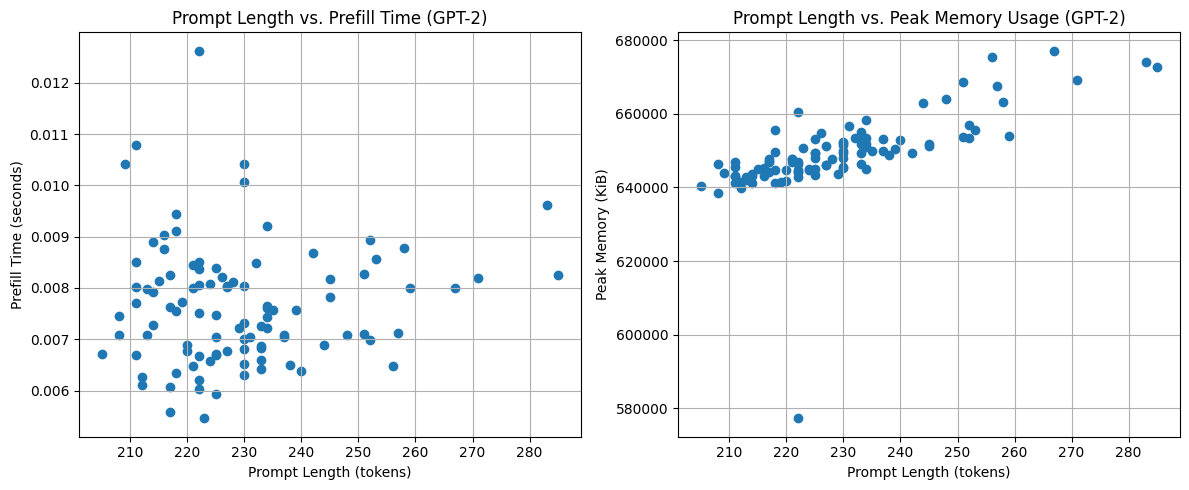

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(prefill_results_df['prompt_length'], prefill_results_df['prefill_time_sec'])
plt.title('Prompt Length vs. Prefill Time (GPT-2)')
plt.xlabel('Prompt Length (tokens)')
plt.ylabel('Prefill Time (seconds)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(prefill_results_df['prompt_length'], prefill_results_df['peak_memory_kib'])
plt.title('Prompt Length vs. Peak Memory Usage (GPT-2)')
plt.xlabel('Prompt Length (tokens)')
plt.ylabel('Peak Memory (KiB)')
plt.grid(True)

plt.tight_layout()
plt.savefig("gpt2_prefill_analysis.png")
print("\nSaved analysis plots to 'gpt2_prefill_analysis.png'")
plt.show()

In [16]:
inference(gpt2_model, gpt2_tokenizer, device=device, prompt_texts=prompt_texts[:100], name="gpt2")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Warming up model for generation benchmark...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Warmup complete

--- Evaluating with KV cache = True ---
Input tokens: 222
Generated tokens: 10
Time taken: 0.076 seconds
Generated part only: ' you \'re talking about . " \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
Total KV Cache Size: 16632.00 KiB

Input tokens: 230
Generated tokens: 50
Time taken: 0.284 seconds
Generated part only: ' , including the " The Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the Song of the'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
Total KV Cache Size: 20088.00 KiB

Input tokens: 221
Generated tokens: 13
Time taken: 0.075 seconds
Generated part only: ' have been seen as a sign of his influence . \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
Total KV Cache Siz

/tmp/ipykernel_222219/2266315744.py:202: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('', inplace=True)


### LLAMA

In [ ]:
from datetime import datetime
import torch, time, numpy as np, pandas as pd
from transformers import LlamaForCausalLM, LlamaTokenizer
import math

def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    
    model.eval()
    total_loss = 0
    total_tokens = 0
    for text in text_list:
        if not text:
            continue
        encodings= tokenizer(text, return_tensors="pt", padding=True, truncation=True)
        input_ids= encodings.input_ids.to(device)
        attention_mask= encodings.attention_mask.to(device)
        target_ids= input_ids.clone()
        target_ids[attention_mask == 0] = -100
        
        with torch.no_grad():
            outputs= model(input_ids, labels=target_ids, attention_mask=attention_mask)
            loss= outputs.loss
            num_tokens= (target_ids != -100).sum().item()
            if num_tokens> 0:
                total_loss += loss.item() * num_tokens
                total_tokens += num_tokens
                
    if total_tokens == 0:
        return float("inf")
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity


def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()

def llama_inference(model, tokenizer, device, prompt_texts, name):
    all_results = []
    cached_throughput = 0
    cached_avg_latency = 0

    print("Warming up model...")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    print("Warmup complete\n")

    for use_cache in (True, False):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        times = []
        total_generated_tokens = 0
        all_predictions = []
        print(f"--- Evaluating with KV cache = {use_cache} ---")

        captured_kv_history = []
        hooks = []
        # llama specific
        if not use_cache:
            def make_hook_for_layernorm(attn_module, layer_id):
                def hook(module, args, output):
                    hidden_states = output
                    q = attn_module.q_proj(hidden_states)
                    k = attn_module.k_proj(hidden_states)
                    v = attn_module.v_proj(hidden_states)
                    captured_kv_history.append({
                        "layer": layer_id, "k_shape": tuple(k.shape), "v_shape": tuple(v.shape),
                        "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)
                    })
                return hook

            for i, layer in enumerate(model.model.layers):
                h = layer.input_layernorm.register_forward_hook(
                    make_hook_for_layernorm(layer.self_attn, i)
                )
                hooks.append(h)

        for i, prompt in enumerate(prompt_texts):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            input_len = inputs["input_ids"].shape[1]
            print(f"Input tokens: {input_len}")
            torch.manual_seed(42)
            captured_kv_history.clear()

            with torch.no_grad():
                start = time.time()
                outputs = model.generate(
                    **inputs, use_cache=use_cache, max_new_tokens=50, min_new_tokens=5,
                    do_sample=False, temperature=1.0, pad_token_id=tokenizer.eos_token_id,
                    return_dict_in_generate=True, output_scores=True
                )
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                elapsed = time.time() - start

            output_len = outputs.sequences.shape[1]
            generated_tokens = output_len - input_len
            total_generated_tokens += generated_tokens
            times.append(elapsed)

            full_text = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
            generated_text = tokenizer.decode(outputs.sequences[0][input_len:], skip_special_tokens=True)
            all_predictions.append(full_text)

            print(f"Generated tokens: {generated_tokens}")
            print(f"Time taken: {elapsed:.3f} seconds")
            print(f"Generated part only: {repr(generated_text)}")
            print("-"*50)
            
            total_kv_bytes = 0
            if use_cache:
                past_key_values = outputs.past_key_values
                print("\nKV Cache Shapes and Sizes per Layer (final state):")
                for layer_idx, (k, v) in enumerate(past_key_values):
                    layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                    total_kv_bytes += layer_bytes
                    #print(f"  Layer {layer_idx}: K {k.shape}, V {v.shape}, Size: {layer_bytes/1024:.2f} KiB")
                print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
            else:
                print("\nKV Shapes and Sizes per Layer (captured at each step):")
                stepwise = {}
                for record in captured_kv_history:
                    layer = record["layer"]
                    kv_size = (record["k_mem"] + record["v_mem"])
                    stepwise.setdefault(layer, []).append(kv_size)
                
                for layer, sizes in stepwise.items():
                    #print(f"  Layer {layer}: step KV sizes (KiB) = {[round(s / 1024, 2) for s in sizes]}")
                    total_kv_bytes += sum(sizes)
                
                print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024:.2f} KiB\n")
            
            result_row = {
                'cache_enabled': use_cache, 'prompt_id': i,
                'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
                'input_tokens': input_len, 'generated_tokens': generated_tokens,
                'total_tokens': output_len, 'time_taken_sec': round(elapsed, 3),
                'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
                'generated_part': generated_text[:200] + "..." if len(generated_text) > 200 else generated_text
            }
            all_results.append(result_row)
            
        for h in hooks:
            h.remove()
        
        avg_latency = np.mean(times) if times else 0
        std_latency = np.std(times) if times else 0
        total_time = sum(times)
        throughput = (total_generated_tokens / total_time) if total_time > 0 else 0
        
        print(f"\nSummary for cache_enabled={use_cache}:")
        print(f"Latency: {round(avg_latency, 3)} ± {round(std_latency, 3)} sec")
        print(f"Throughput: {round(throughput, 2)} tokens/sec")

        print(f"Calculating perplexity for cache={use_cache}...")
        avg_perplexity = calculate_perplexity(model, tokenizer, prompt_texts, device)
        print(f"Average Perplexity: {avg_perplexity:.4f}")

        summary_row = {
            'cache_enabled': use_cache, 'prompt_id': 'SUMMARY',
            'prompt_text': f'Summary for cache={use_cache}', 'input_tokens': '',
            'generated_tokens': total_generated_tokens, 'total_tokens': '',
            'time_taken_sec': round(total_time, 3), 'kv_cache_size_kib': '',
            'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3),
            'throughput_tokens_per_sec': round(throughput, 2),
            'avg_perplexity': round(avg_perplexity, 4) if avg_perplexity != float('inf') else 'N/A',
            'generated_part': f'Total generated: {total_generated_tokens} tokens'
        }
        all_results.append(summary_row)

        if use_cache:
            cached_throughput = throughput
            cached_avg_latency = avg_latency
        else:
            print("-" * 20)
            if cached_throughput > 0 and throughput > 0:
                throughput_speedup = cached_throughput / throughput
                print(f"--> Throughput Speedup Factor: {throughput_speedup:.2f}x")
            if cached_avg_latency > 0 and avg_latency > 0:
                latency_speedup = avg_latency / cached_avg_latency
                print(f"--> Average Latency Speedup Factor: {latency_speedup:.2f}x")
        print("="*60 + "\n")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"kv_cache_results_{name}_{timestamp}.xlsx"
    df = pd.DataFrame(all_results)
    df.to_excel(filename, index=False)
    print(f"Results saved to {filename}")

In [43]:
prefill_results_df_llama = benchmark_prefilling(model=llama_model, tokenizer=llama_tokenizer, device=device, prompt_texts=prompt_texts[:100])


--- Running Prefilling Benchmark ---
This measures the performance of processing the initial prompt.
Prompt 1/100 | Length: 271 tokens | Prefill Time: 0.0520s | Peak memory: 5356428.50 KiB
Prompt 2/100 | Length: 260 tokens | Prefill Time: 0.0562s | Peak memory: 5400210.50 KiB
Prompt 3/100 | Length: 251 tokens | Prefill Time: 0.0466s | Peak memory: 5395816.50 KiB
Prompt 4/100 | Length: 285 tokens | Prefill Time: 0.0520s | Peak memory: 5400046.50 KiB
Prompt 5/100 | Length: 308 tokens | Prefill Time: 0.0575s | Peak memory: 5410275.50 KiB
Prompt 6/100 | Length: 244 tokens | Prefill Time: 0.0519s | Peak memory: 5403053.50 KiB
Prompt 7/100 | Length: 295 tokens | Prefill Time: 0.0624s | Peak memory: 5400853.50 KiB
Prompt 8/100 | Length: 278 tokens | Prefill Time: 0.0593s | Peak memory: 5406309.50 KiB
Prompt 9/100 | Length: 270 tokens | Prefill Time: 0.0584s | Peak memory: 5402020.50 KiB
Prompt 10/100 | Length: 251 tokens | Prefill Time: 0.0539s | Peak memory: 5397238.50 KiB
Prompt 11/100 | L


Saved analysis plots to 'tinyllama_prefill_analysis.png'


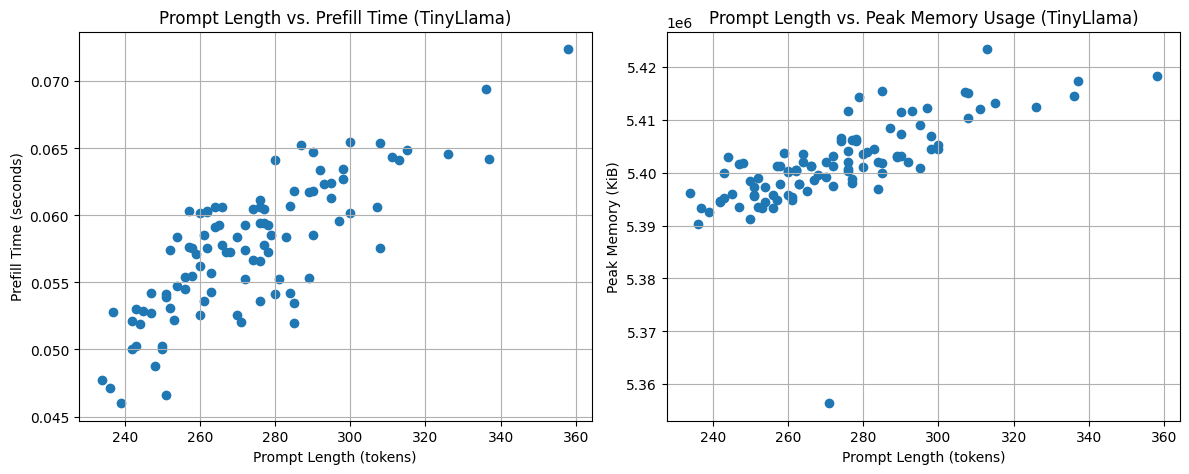

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(prefill_results_df_llama['prompt_length'], prefill_results_df_llama['prefill_time_sec'])
plt.title('Prompt Length vs. Prefill Time (TinyLlama)')
plt.xlabel('Prompt Length (tokens)')
plt.ylabel('Prefill Time (seconds)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(prefill_results_df_llama['prompt_length'], prefill_results_df_llama['peak_memory_kib'])
plt.title('Prompt Length vs. Peak Memory Usage (TinyLlama)')
plt.xlabel('Prompt Length (tokens)')
plt.ylabel('Peak Memory (KiB)')
plt.grid(True)

plt.tight_layout()
plt.savefig("tinyllama_prefill_analysis.png")
print("\nSaved analysis plots to 'tinyllama_prefill_analysis.png'")
plt.show()

In [19]:
llama_inference(llama_model, llama_tokenizer, device=device, prompt_texts=prompt_texts[:100], name="llama")

Warming up model...


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


Warmup complete

--- Evaluating with KV cache = True ---
Input tokens: 271
Generated tokens: 9
Time taken: 0.191 seconds
Generated part only: 'you \'re doing . " \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
Total KV Cache Size: 12276.00 KiB

Input tokens: 260
Generated tokens: 23
Time taken: 0.370 seconds
Generated part only: 'in the form of a single narrator , and his poems are often translated into different languages . \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
Total KV Cache Size: 12408.00 KiB

Input tokens: 251
Generated tokens: 15
Time taken: 0.245 seconds
Generated part only: 'has been a major issue in the history of Chinese literature . \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
Total KV Cache Size: 11660.00 KiB

Input tokens: 285
Generated tokens: 31
Time taken: 0.498 seconds
Generated part

## BENCHMARK RESULTS

Loading Llama data from: kv_cache_results_llama_20250909_164201.xlsx
Loading GPT-2 data from: kv_cache_results_gpt2_20250909_163647.xlsx
Saved plot: overall_avg_latency.png


/tmp/ipykernel_222889/452796411.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df.sort_values('avg_latency_sec', ascending=False), x='plot_group', y='avg_latency_sec', palette='viridis')
/tmp/ipykernel_222889/452796411.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df.sort_values('throughput_tokens_per_sec', ascending=False), x='plot_group', y='throughput_tokens_per_sec', palette='plasma')


Saved plot: overall_avg_throughput.png
Saved plot: avg_perplexity_cache_enabled.png


/tmp/ipykernel_222889/452796411.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perplexity_cache_enabled_df.sort_values('avg_perplexity'), x='model', y='avg_perplexity', palette='crest')


Saved plot: throughput_vs_latency.png


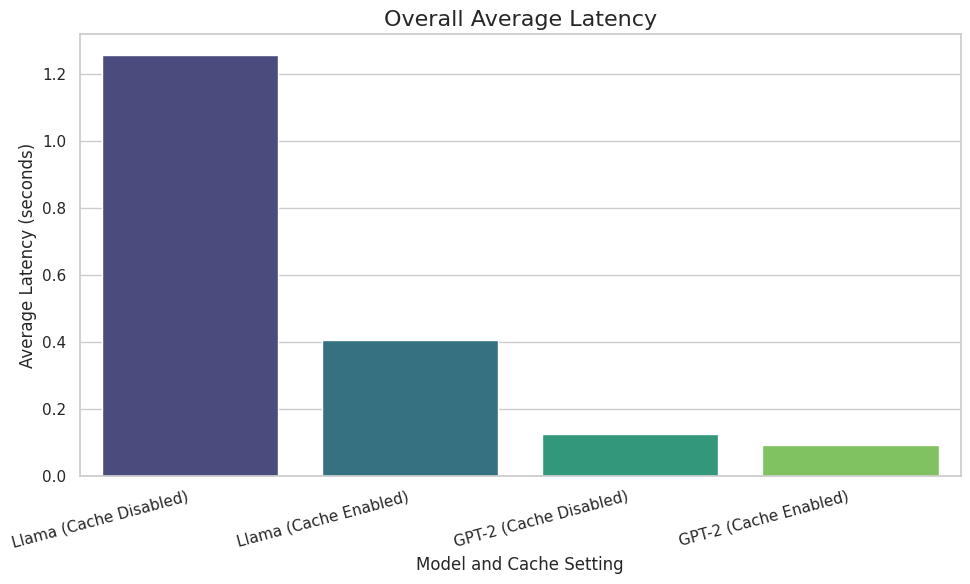

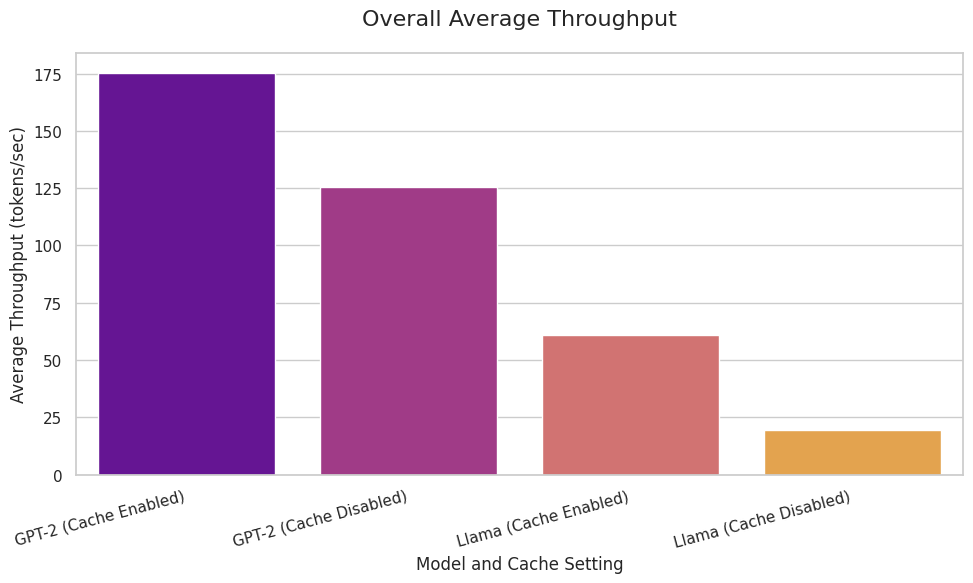

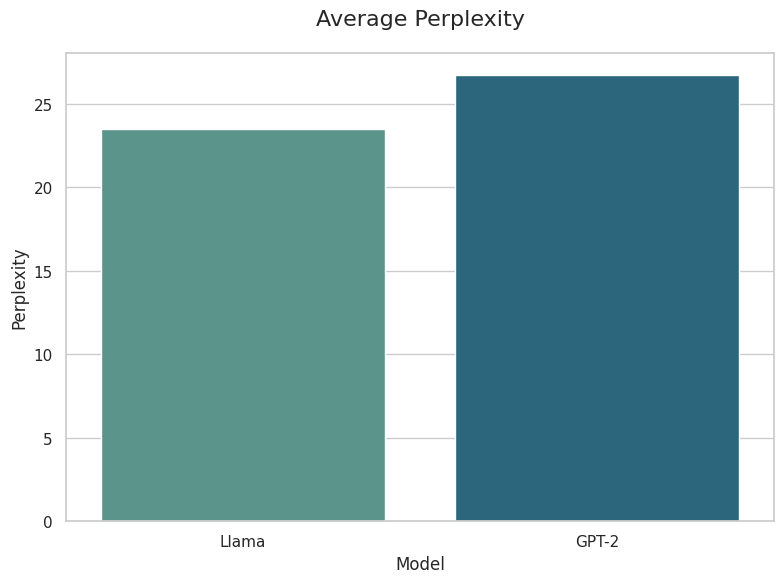

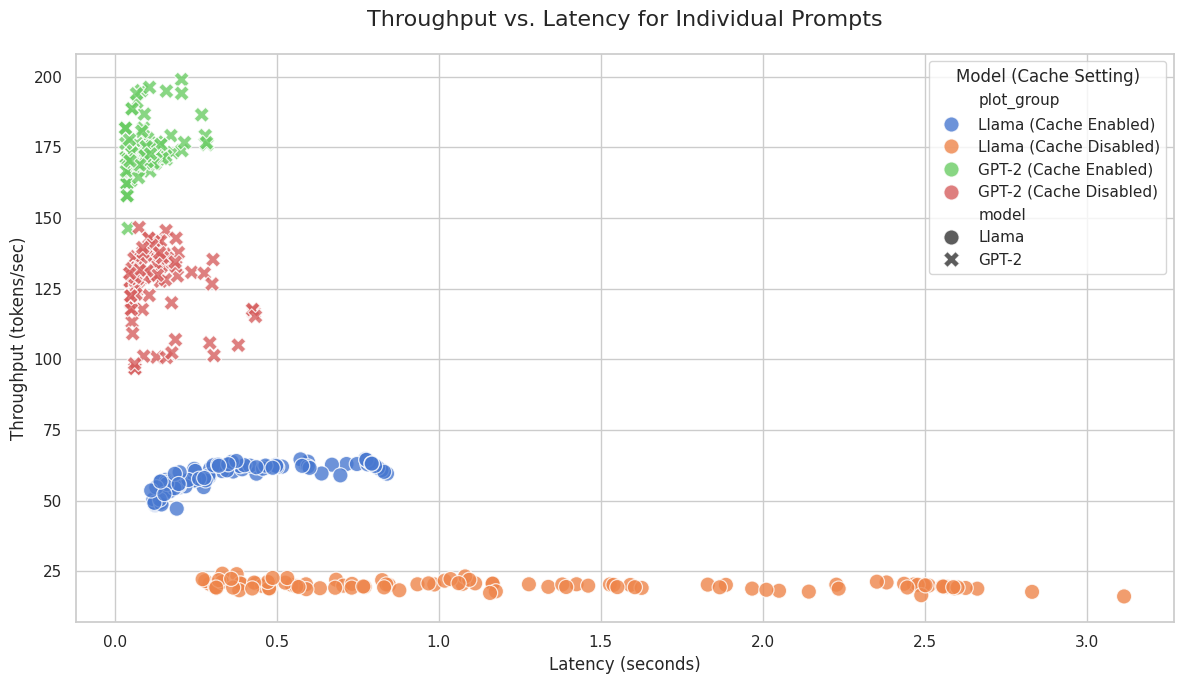

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


llama_file = 'kv_cache_results_llama_20250909_164201.xlsx'
gpt_file = 'kv_cache_results_gpt2_20250909_163647.xlsx'

try:
    print(f"Loading Llama data from: {llama_file}")
    print(f"Loading GPT-2 data from: {gpt_file}")

    df_llama = pd.read_excel(llama_file)
    df_llama['model'] = 'Llama'
    df_gpt = pd.read_excel(gpt_file)
    df_gpt['model'] = 'GPT-2'
    df_combined = pd.concat([df_llama, df_gpt], ignore_index=True)

    df_combined['cache_setting'] = df_combined['cache_enabled'].apply(lambda x: 'Cache Enabled' if x else 'Cache Disabled')
    df_combined['plot_group'] = df_combined['model'] + ' (' + df_combined['cache_setting'] + ')'

    summary_df = df_combined[df_combined['prompt_id'] == 'SUMMARY'].copy()
    per_prompt_df = df_combined[df_combined['prompt_id'] != 'SUMMARY'].copy()
    
    per_prompt_df['time_taken_sec'] = pd.to_numeric(per_prompt_df['time_taken_sec'], errors='coerce')
    per_prompt_df['generated_tokens'] = pd.to_numeric(per_prompt_df['generated_tokens'], errors='coerce')
    per_prompt_df = per_prompt_df.dropna(subset=['time_taken_sec', 'generated_tokens'])
    per_prompt_df['throughput'] = per_prompt_df.apply(
        lambda row: row['generated_tokens'] / row['time_taken_sec'] if row['time_taken_sec'] > 0 else 0, axis=1
    )


    sns.set_theme(style="whitegrid", palette="muted")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df.sort_values('avg_latency_sec', ascending=False), x='plot_group', y='avg_latency_sec', palette='viridis')
    plt.title('Overall Average Latency', fontsize=16)
    plt.xlabel('Model and Cache Setting', fontsize=12)
    plt.ylabel('Average Latency (seconds)', fontsize=12)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig('overall_avg_latency.png')
    print("Saved plot: overall_avg_latency.png")

    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df.sort_values('throughput_tokens_per_sec', ascending=False), x='plot_group', y='throughput_tokens_per_sec', palette='plasma')
    plt.title('Overall Average Throughput', fontsize=16, pad=20)
    plt.xlabel('Model and Cache Setting', fontsize=12)
    plt.ylabel('Average Throughput (tokens/sec)', fontsize=12)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig('overall_avg_throughput.png')
    print("Saved plot: overall_avg_throughput.png")
    plt.figure(figsize=(8, 6))
    summary_df['avg_perplexity'] = pd.to_numeric(summary_df['avg_perplexity'], errors='coerce')
    
    perplexity_cache_enabled_df = summary_df[summary_df['cache_enabled'] == True]
    
    sns.barplot(data=perplexity_cache_enabled_df.sort_values('avg_perplexity'), x='model', y='avg_perplexity', palette='crest')
    plt.title('Average Perplexity', fontsize=16, pad=20)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Perplexity', fontsize=12)
    plt.tight_layout()
    plt.savefig('avg_perplexity_cache_enabled.png')
    print("Saved plot: avg_perplexity_cache_enabled.png")


    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=per_prompt_df, x='time_taken_sec', y='throughput', hue='plot_group', style='model', s=120, alpha=0.8)
    plt.title('Throughput vs. Latency for Individual Prompts', fontsize=16, pad=20)
    plt.xlabel('Latency (seconds)', fontsize=12)
    plt.ylabel('Throughput (tokens/sec)', fontsize=12)
    plt.legend(title='Model (Cache Setting)')
    plt.tight_layout()
    plt.savefig('throughput_vs_latency.png')
    print("Saved plot: throughput_vs_latency.png")

except FileNotFoundError as e:
    print(f"Error: A specified Excel file was not found.")
    print(f"Please make sure these files are in the same directory as your script:")
    print(f" - {llama_file}")
    print(f" - {gpt_file}")
    print(f"Details: {e}")